In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("pastCBB.csv")

,Result,ADJDE
0,1.0,91.272563
1,2.0,91.791875
2,4.0,93.463125
3,8.0,93.600284
4,16.0,94.044330
5,32.0,95.808134
6,64.0,99.247947


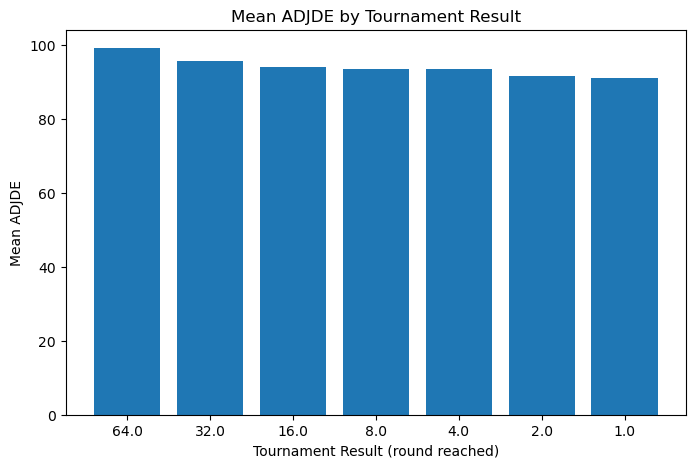

   Result      ADJDE
6    64.0  99.247947
5    32.0  95.808134
4    16.0  94.044330
3     8.0  93.600284
2     4.0  93.463125
1     2.0  91.791875
0     1.0  91.272563


In [5]:
summary = df.groupby("Result")["ADJDE"].mean().reset_index()
summary = summary.sort_values("Result", ascending=False)

# Plot
plt.figure(figsize=(8,5))
plt.bar(summary["Result"].astype(str), summary["ADJDE"])
plt.xlabel("Tournament Result (round reached)")
plt.ylabel("Mean ADJDE")
plt.title("Mean ADJDE by Tournament Result")
plt.show()
print(summary)

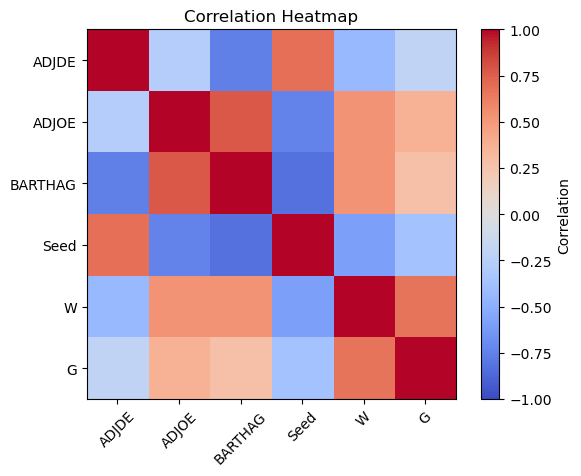

In [6]:
corr = df[["ADJDE","ADJOE","BARTHAG","Seed","W","G"]].corr()
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

<Figure size 1400x800 with 0 Axes>

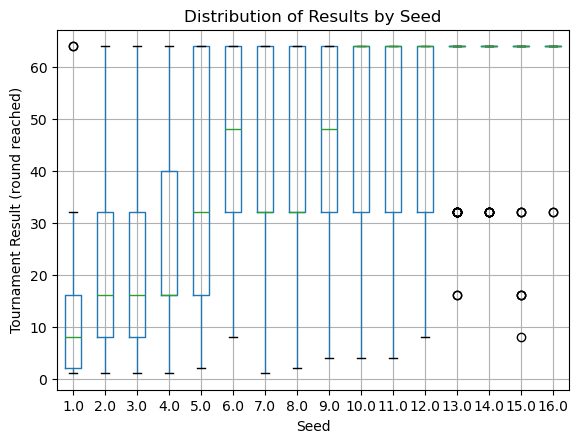

In [15]:
plt.figure(figsize=(14,8))
df.boxplot(column="Result", by="Seed")
plt.xlabel("Seed")
plt.ylabel("Tournament Result (round reached)")
plt.title("Distribution of Results by Seed")
plt.suptitle("")  # removes default pandas title
plt.savefig("results_by_seed.png", dpi=300, bbox_inches="tight")  # high-res PNG
plt.savefig("results_by_seed.pdf", dpi=300, bbox_inches="tight")  # vector PDF (scales perfectly)
plt.show()


<Figure size 1200x600 with 0 Axes>

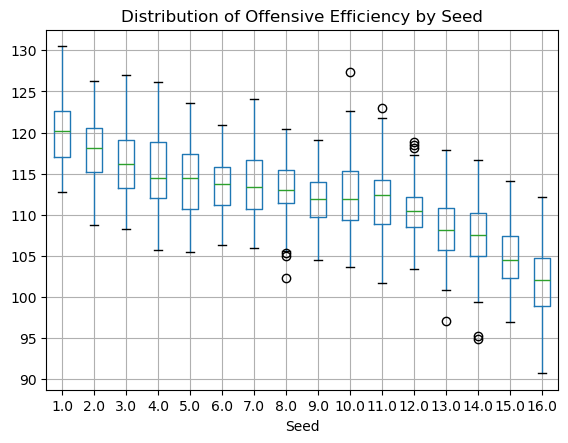

<Figure size 1200x600 with 0 Axes>

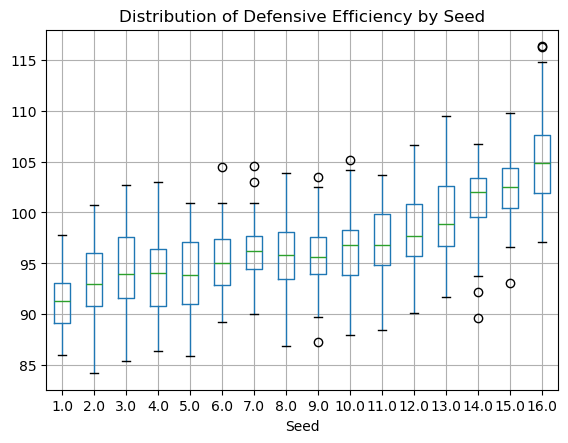

In [16]:
plt.figure(figsize=(12,6))
df.boxplot(column="ADJOE", by="Seed")
plt.title("Distribution of Offensive Efficiency by Seed")
plt.suptitle("")
plt.show()

plt.figure(figsize=(12,6))
df.boxplot(column="ADJDE", by="Seed")
plt.title("Distribution of Defensive Efficiency by Seed")
plt.suptitle("")
plt.show()

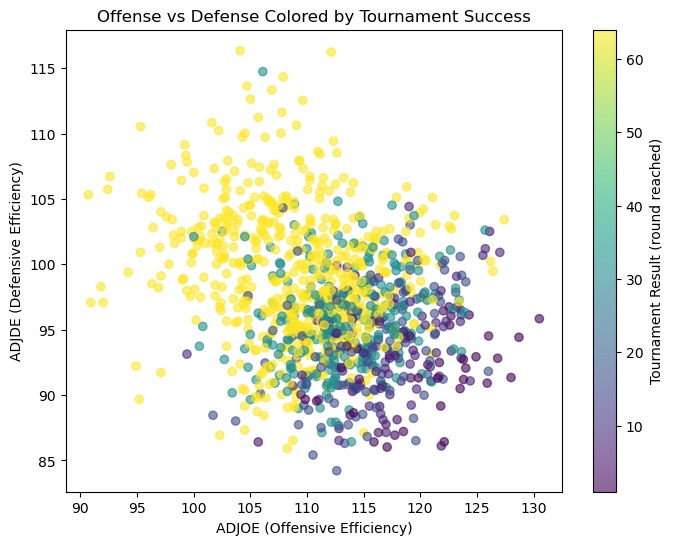

In [20]:
plt.figure(figsize=(8,6))
plt.scatter(df["ADJOE"], df["ADJDE"], c=df["Result"], cmap="viridis", alpha=0.6)
plt.colorbar(label="Tournament Result (round reached)")
plt.xlabel("ADJOE (Offensive Efficiency)")
plt.ylabel("ADJDE (Defensive Efficiency)")
plt.title("Offense vs Defense Colored by Tournament Success")
plt.show()


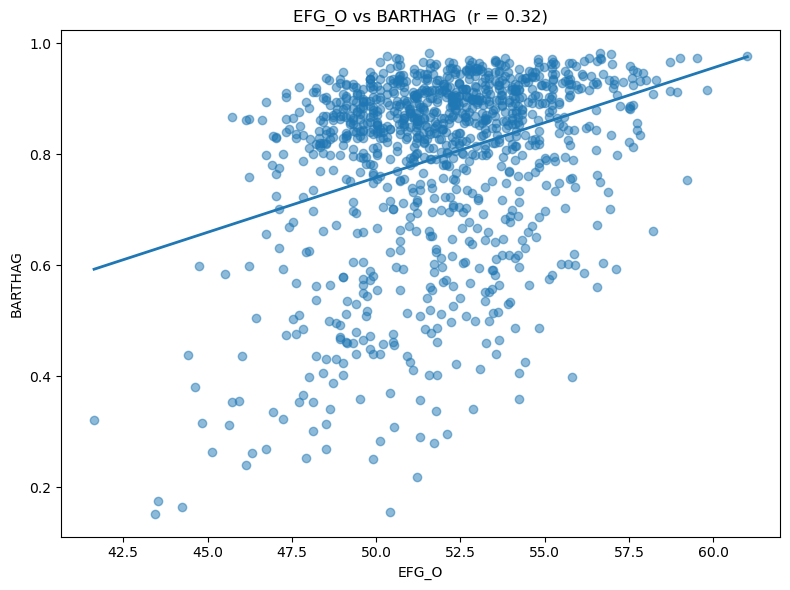

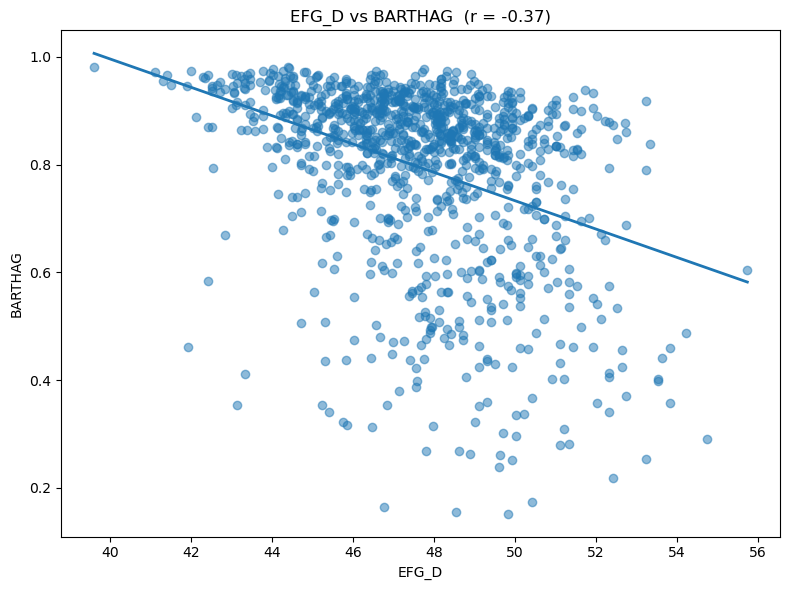

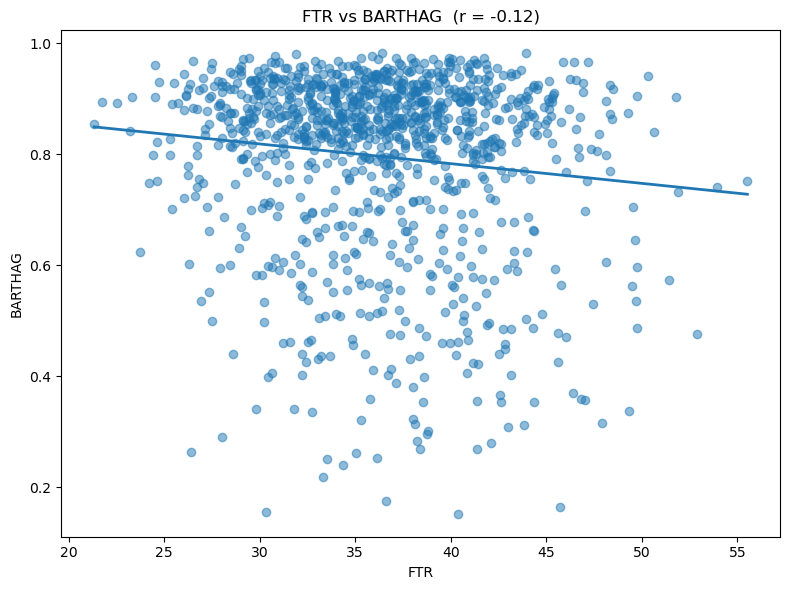

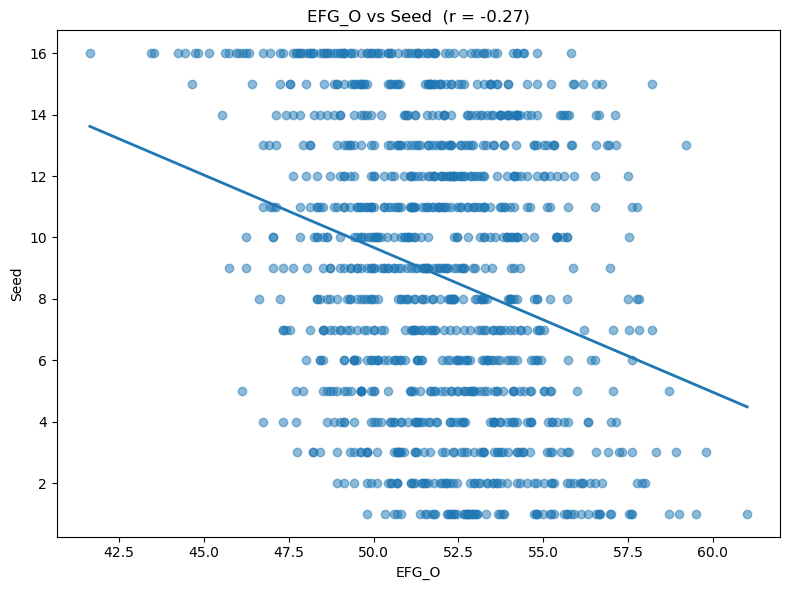

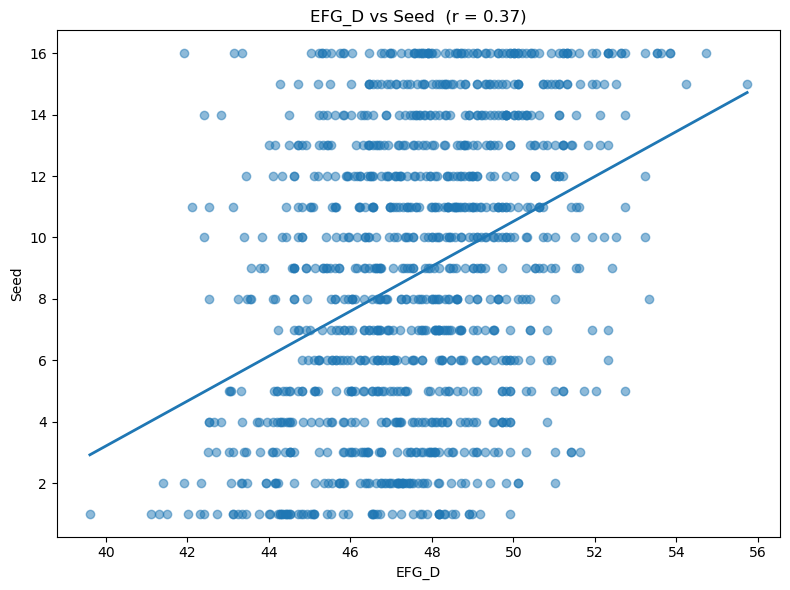

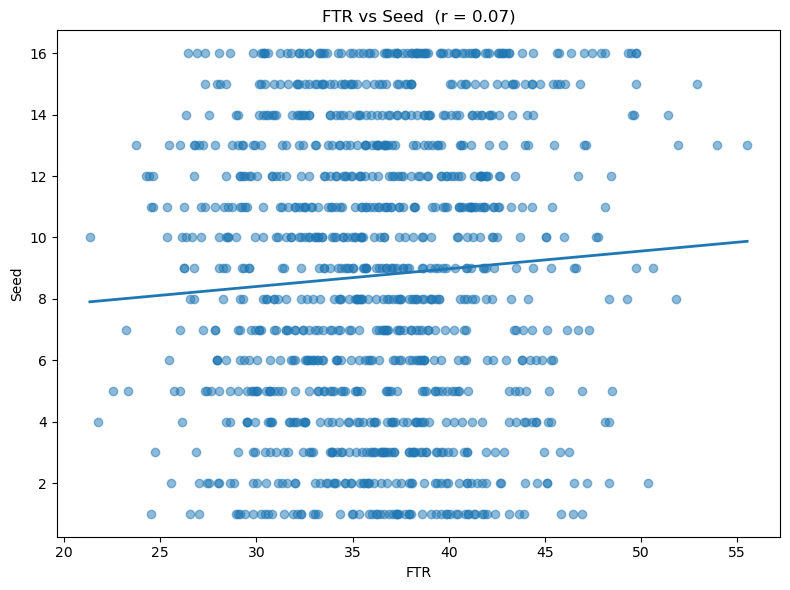

In [21]:
candidate_predictors = ["EFG_O", "EFG_D", "3P_O", "2P_O", "FTR"]
predictors = [c for c in candidate_predictors if c in df.columns]

targets = [t for t in ["BARTHAG", "Seed"] if t in df.columns]

def scatter_with_trend(x, y, x_label, y_label, title_prefix, save_name=None):
    # Clean rows
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if x.size < 3:
        return

    # Correlation + trendline
    r = np.corrcoef(x, y)[0,1]
    m_slope, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 200)
    ys = m_slope * xs + b

    # Plot
    plt.figure(figsize=(8,6))
    plt.scatter(x, y, alpha=0.5)
    plt.plot(xs, ys, linewidth=2)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(f"{title_prefix}  (r = {r:.2f})")
    plt.tight_layout()
    if save_name:
        plt.savefig(save_name, dpi=200, bbox_inches="tight")
    plt.show()

# Generate plots
for target in targets:
    for pred in predictors:
        scatter_with_trend(
            x=df[pred].astype(float).values,
            y=df[target].astype(float).values,
            x_label=pred,
            y_label=target,
            title_prefix=f"{pred} vs {target}",
            save_name=f"{pred}_vs_{target}.png"  # remove if you don't want files saved
        )

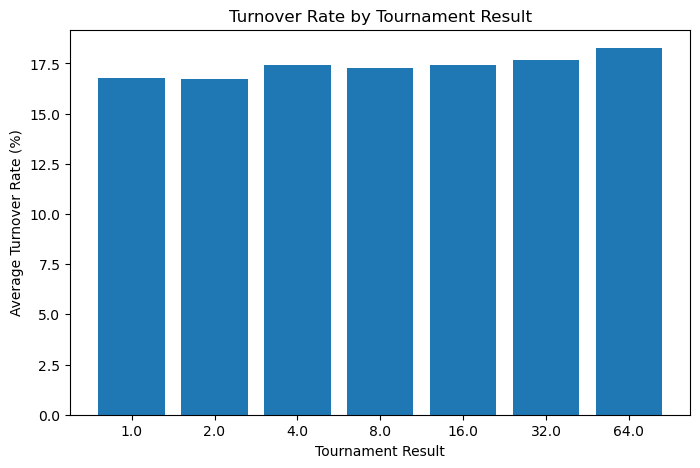

In [23]:
summary = df.groupby("Result")["TOR"].mean().reset_index()
plt.figure(figsize=(8,5))
plt.bar(summary["Result"].astype(str), summary["TOR"])
plt.xlabel("Tournament Result")
plt.ylabel("Average Turnover Rate (%)")
plt.title("Turnover Rate by Tournament Result")
plt.show()

<Figure size 700x500 with 0 Axes>

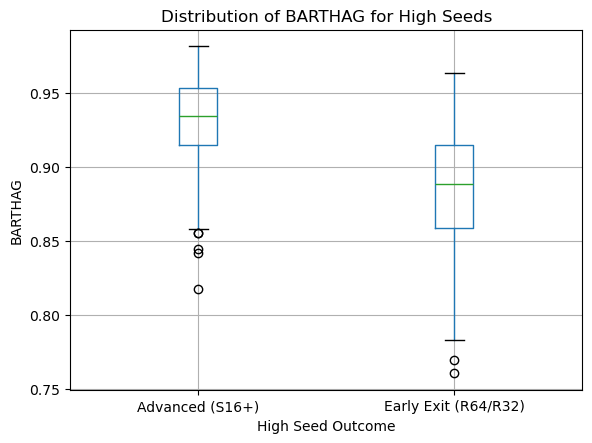

              ExitGroup   BARTHAG
0       Advanced (S16+)  0.931242
1  Early Exit (R64/R32)  0.884559


In [26]:
# Filter only high seeds (1–8) and make a copy
high_seeds = df[df["Seed"] <= 8].copy()

# Define "early exit" vs "advanced"
high_seeds["ExitGroup"] = high_seeds["Result"].apply(
    lambda r: "Early Exit (R64/R32)" if r in [64, 32] else "Advanced (S16+)"
)

# Group and compute mean BARTHAG
summary = high_seeds.groupby("ExitGroup")["BARTHAG"].mean().reset_index()

plt.figure(figsize=(7,5))
high_seeds.boxplot(column="BARTHAG", by="ExitGroup")
plt.xlabel("High Seed Outcome")
plt.ylabel("BARTHAG")
plt.title("Distribution of BARTHAG for High Seeds")
plt.suptitle("")
plt.show()

print(summary)


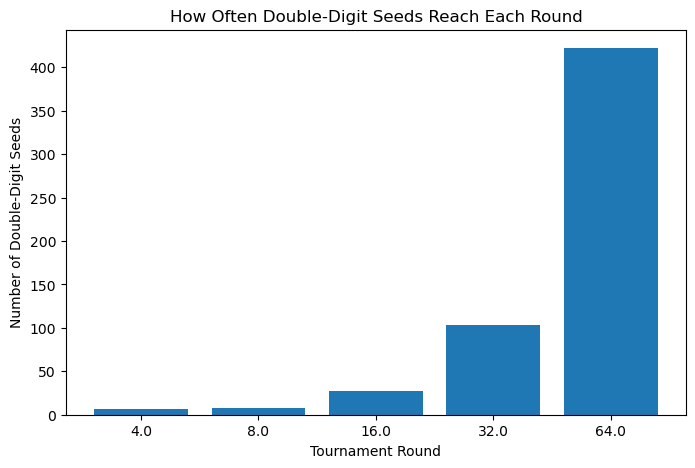

In [27]:
underdogs = df[df["Seed"] >= 9]

summary = underdogs.groupby("Result")["Seed"].count().reset_index()

plt.figure(figsize=(8,5))
plt.bar(summary["Result"].astype(str), summary["Seed"])
plt.xlabel("Tournament Round")
plt.ylabel("Number of Double-Digit Seeds")
plt.title("How Often Double-Digit Seeds Reach Each Round")
plt.show()


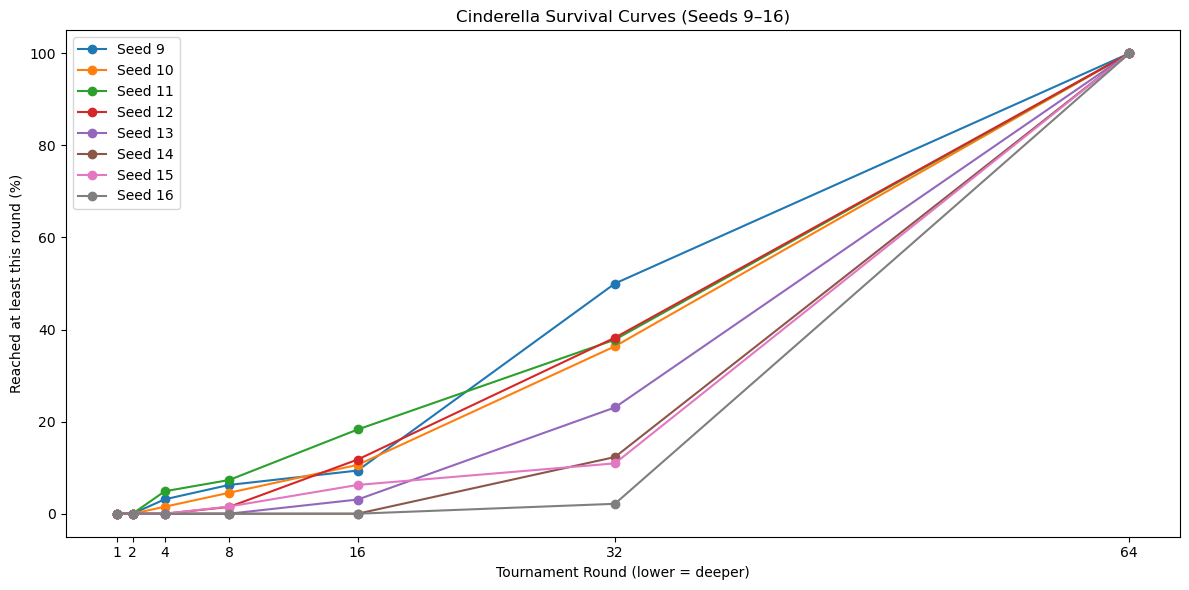

In [29]:
rounds_present = sorted(df["Result"].dropna().astype(int).unique(), reverse=True)
target_rounds = [r for r in [64,32,16,8,4,2,1] if r in rounds_present]

plt.figure(figsize=(12,6))
for seed in range(9, 17):  # Cinderella seeds 9–16
    g = df[df["Seed"] == seed]
    if len(g) == 0:
        continue
    # FIX: survive to round r == reached at least r
    probs = [(g["Result"] <= r).mean() * 100 for r in target_rounds]
    plt.plot(target_rounds, probs, marker="o", label=f"Seed {seed}")

plt.xlabel("Tournament Round (lower = deeper)")
plt.ylabel("Reached at least this round (%)")
plt.title("Cinderella Survival Curves (Seeds 9–16)")
plt.xticks(target_rounds, [str(r) for r in target_rounds])
plt.legend()
plt.tight_layout()
plt.show()